In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

from pprint import pprint

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

/home/inoue/MyGithub/Book_BayesInference/.venv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Running on PyMC v5.27.0
Running on ArviZ v0.23.0


### ABテストの効果検証

| | | 鈴木さん | 山田さん |
| :-- | :-- | --: | --: |
| 従来のページA | 表示数 | 40 | 1200 |
| | クリック数 | 2 | 60 |
| | クリック率 | 5% | 5% |
| 改善後のページB | 表示数 | 25 | 1600 |
| | クリック数 | 2 | 110 |
| | クリック率 | 8% | 6.88% |

### 鈴木さんのケース

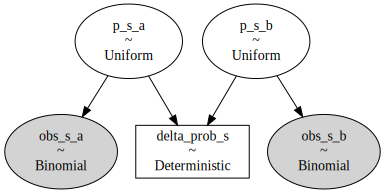

In [2]:
model_suzuki = pm.Model()

# モデル定義
with model_suzuki:
    # クリック率pの事前分布は一様分布
    p_s_a = pm.Uniform('p_s_a', lower=0.0, upper=1.0)
    p_s_b = pm.Uniform('p_s_b', lower=0.0, upper=1.0)

    # 二項分布で確率モデルを定義
    # n: 表示数, observed: ヒット数
    obs_s_a = pm.Binomial('obs_s_a', p=p_s_a, n=40, observed=2)
    obs_s_b = pm.Binomial('obs_s_b', p=p_s_b, n=25, observed=2)

    # 新たな確率変数 (p_s_b - p_s_a) : 差の正負で効果を判断
    delta_prob_s = pm.Deterministic('delta_prob_s', p_s_b - p_s_a)

# 確率モデルの可視化
g_suzuki = pm.model_to_graphviz(model_suzuki)
display(g_suzuki)

In [3]:
# サンプリング(MCMC)
with model_suzuki:
    idata_suzuki = pm.sample(random_seed=42, target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_s_a, p_s_b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


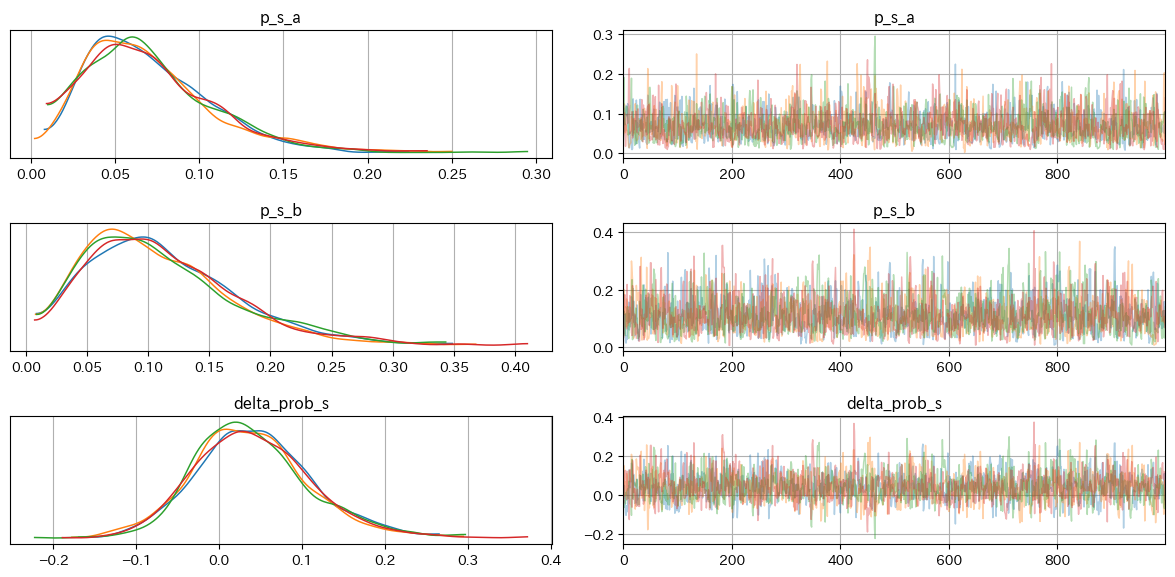

In [4]:
# 推論結果の可視化
az.plot_trace(idata_suzuki, compact=False)
plt.tight_layout()

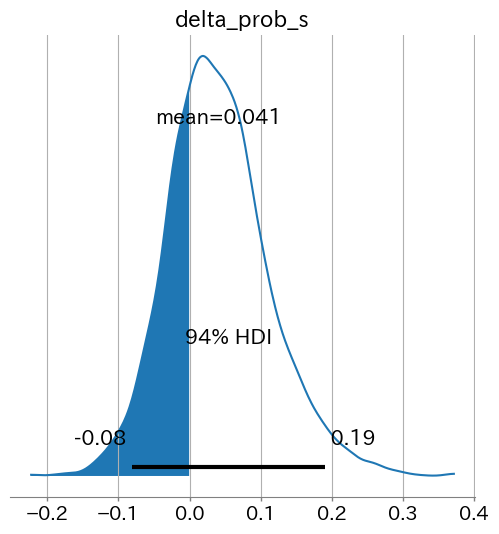

In [5]:
# 差分確率変数が0以下の確率を求める
ax = az.plot_posterior(idata_suzuki, var_names=['delta_prob_s'])
xx, yy = ax.get_lines()[0].get_data()
ax.fill_between(xx[xx<0], yy[xx<0])

画面Aの方がクリック率が高い確率を計算

In [12]:
# サンプリング結果からdelta_probの値を抽出
delta_prob_s = idata_suzuki['posterior'].data_vars['delta_prob_s']
delta_prob_s

<xarray.DataArray 'delta_prob_s' (chain: 4, draw: 1000)> Size: 32kB
array([[ 0.027, -0.018,  0.048, ...,  0.109, -0.026,  0.028],
       [ 0.117,  0.149, -0.009, ..., -0.095,  0.074,  0.045],
       [ 0.065, -0.065, -0.032, ..., -0.070, -0.068,  0.036],
       [-0.043, -0.042,  0.077, ...,  0.118,  0.040, -0.049]],
      shape=(4, 1000))
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [13]:
delta_prob_s_values = delta_prob_s.values.reshape(-1)
delta_prob_s_values

array([ 0.027, -0.018,  0.048, ...,  0.118,  0.040, -0.049], shape=(4000,))

In [15]:
# delta_probの値がマイナスだった件数
n1_s = (delta_prob_s_values < 0).sum()

# 全サンプル数
n_s = len(delta_prob_s_values)

# 比率計算
n1_rate_s = n1_s / n_s

print(f"鈴木さんのケース 画面Aのクリック率が高い確率: {n1_rate_s*100:.2f}%")

鈴木さんのケース 画面Aのクリック率が高い確率: 29.00%


#### 山田さんのケース

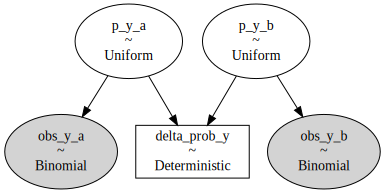

In [16]:
model_yamada = pm.Model()

# モデル定義
with model_yamada:
    # クリック率pの事前分布は一様分布
    p_y_a = pm.Uniform('p_y_a', lower=0.0, upper=1.0)
    p_y_b = pm.Uniform('p_y_b', lower=0.0, upper=1.0)

    # 二項分布で確率モデルを定義
    # n: 表示数, observed: ヒット数
    obs_y_a = pm.Binomial('obs_y_a', p=p_y_a, n=1200, observed=60)
    obs_y_b = pm.Binomial('obs_y_b', p=p_y_b, n=1600, observed=110)

    # 新たな確率変数 (p_y_b - p_y_a) : 差の正負で効果を判断
    delta_prob_y = pm.Deterministic('delta_prob_y', p_y_b - p_y_a)

# 確率モデルの可視化
g_yamada = pm.model_to_graphviz(model_yamada)
display(g_yamada)

In [17]:
# サンプリング(MCMC)
with model_yamada:
    idata_yamada = pm.sample(random_seed=42, target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_y_a, p_y_b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


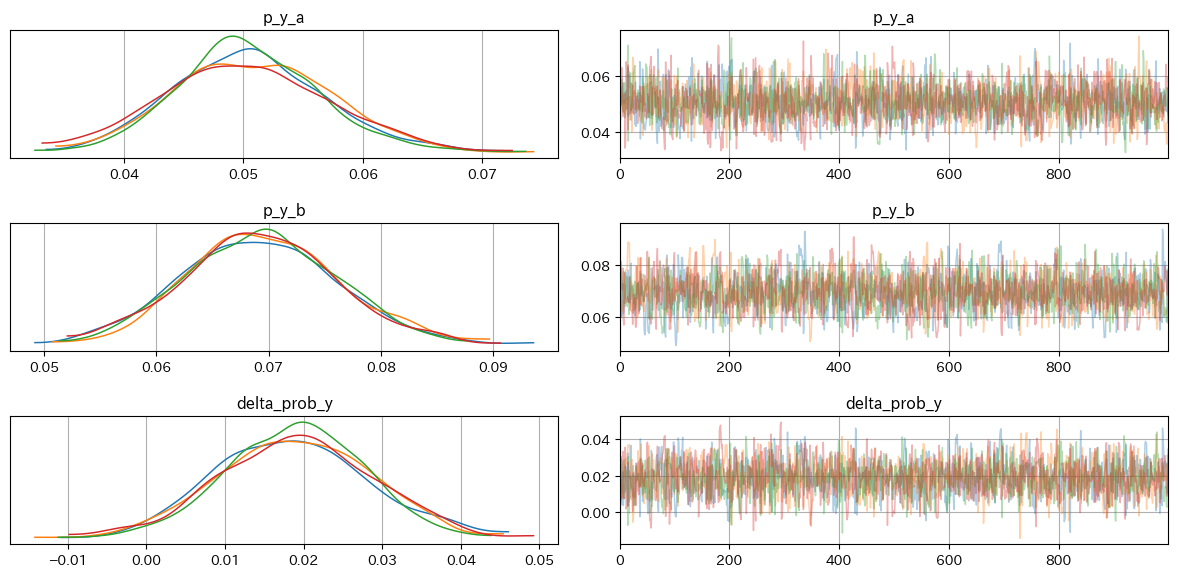

In [18]:
# 推論結果の可視化
az.plot_trace(idata_yamada, compact=False)
plt.tight_layout()

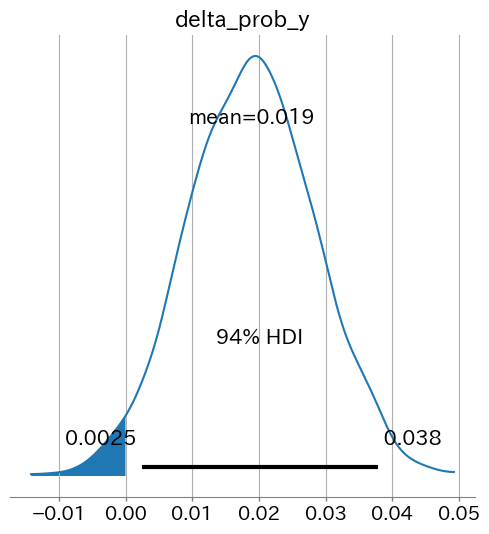

In [19]:
# 差分確率変数が0以下の確率を求める
ax = az.plot_posterior(idata_yamada, var_names=['delta_prob_y'])
xx, yy = ax.get_lines()[0].get_data()
ax.fill_between(xx[xx<0], yy[xx<0])

画面Aの方のクリック率が高い確率を調査

In [21]:
# サンプリング結果からdelta_probの値を抽出
delta_prob_y = idata_yamada['posterior'].data_vars['delta_prob_y']
delta_prob_y_values = delta_prob_y.values.reshape(-1)

# delta_probの値がマイナスだった件数
n1_y = (delta_prob_y_values < 0).sum()

# 全サンプル数
n_y = len(delta_prob_y_values)

# 比率計算
n1_rate_y = n1_y / n_y

print(f"山田さんのケース 画面Aのクリック率が高い確率: {n1_rate_y*100:.2f}%")

山田さんのケース 画面Aのクリック率が高い確率: 2.43%


##### クリック率pの確率分布がベータ分布だと最初からわかっていた場合
+ 事前分布が一様分布，尤度関数が二項分布，事後分布はにベータ分布になる
+ 上記は，組み合わせが決まっている共役な一例

鈴木さんを対象にしたベータ分布によるABテストのシミュレーション

Sampling: [p_a, p_b]


Text(0.5, 1.0, '鈴木さんケース 画面Aのほうがクリック率が高い確率(別海): 29.85%')

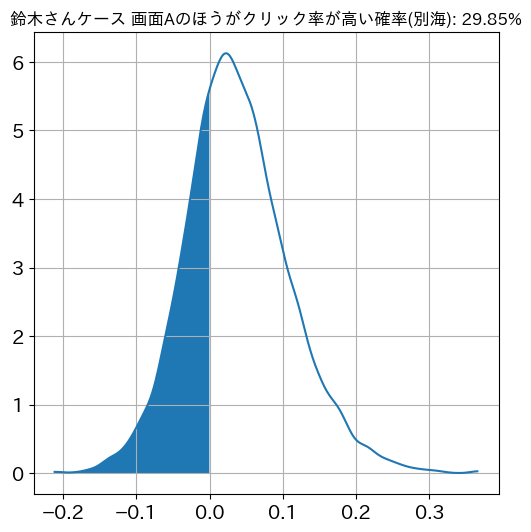

In [22]:
# 画面A 成功2回 失敗38回
alpha_a = 2 + 1
beta_a = 38 + 1

# 画面B 成功2回 失敗23回
alpha_b = 2 + 1
beta_b = 23 + 1

model_suzuki_beta = pm.Model()
with model_suzuki_beta:
    p_a = pm.Beta('p_a', alpha=alpha_a, beta=beta_a)
    p_b = pm.Beta('p_b', alpha=alpha_b, beta=beta_b)

    # 事前分布から取得(今回はベイズ推論を使わない)
    samples_s_beta = pm.sample_prior_predictive(random_seed=42, samples=10000)

# サンプル値抽出
p_a_samples_s_beta = samples_s_beta['prior']['p_a'].values.reshape(-1)
p_b_samples_s_beta = samples_s_beta['prior']['p_b'].values.reshape(-1)

# delta_prob
delta_a_b_s_beta = p_b_samples_s_beta - p_a_samples_s_beta

# delta_probの値がマイナスの件数
n1_sb = (delta_a_b_s_beta < 0).sum()

# 全サンプル数
n_sb = len(delta_a_b_s_beta)

# 比率
n1_rate_sb = n1_sb / n_sb

# 可視化
ax = az.plot_dist(delta_a_b_s_beta)
xx, yy = ax.get_lines()[0].get_data()
ax.fill_between(xx[xx<0], yy[xx<0])

title = f"鈴木さんケース 画面Aのほうがクリック率が高い確率(別海): {n1_rate_sb*100:.2f}%"
ax.set_title(title, fontsize=12)

山田さんのベータ分布による調査は省略